# ☀️ Solar Power Forecasting — 1-Hour Ahead Prediction
**Model:** LightGBM  
**Target:** `target_solar_1h` — total AC power output 60 minutes ahead  
**Data sources:** InfluxDB (inverter telemetry + weather observations) · Open-Meteo Historical Forecast API

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — Imports and Connections
# ─────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dotenv import load_dotenv
import os
import ssl
import certifi

from influxdb_client import InfluxDBClient
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

load_dotenv()
# 1. Create a clean SSL context using certifi's bundle
ssl_context = ssl.create_default_context(cafile=certifi.where())

# ── InfluxDB connection settings ──────────────────────────────
INFLUX_URL   = "https://influx.htetarkar.online"
INFLUX_TOKEN = os.getenv("influxdb_token")  # ← fill in your token
INFLUX_ORG   = "essco"
INFLUX_BUCKET = "essco_energy_data"

client    = InfluxDBClient(url=INFLUX_URL, token=INFLUX_TOKEN, org=INFLUX_ORG, ssl_context=ssl_context)
query_api = client.query_api()

print("✅ InfluxDB client initialised")
print(f"   URL : {INFLUX_URL}")
print(f"   Org : {INFLUX_ORG}")
print(f"   Bucket: {INFLUX_BUCKET}")

✅ InfluxDB client initialised
   URL : https://influx.htetarkar.online
   Org : essco
   Bucket: essco_energy_data


In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — Query Inverter Data
# ─────────────────────────────────────────────────────────────

inverter_query = """
from(bucket: "essco_energy_data")
  |> range(start: -30d)
  |> filter(fn: (r) => r["_measurement"] == "inverter")
  |> filter(fn: (r) => r["siteId"] == "ESSCO_49453AB5")
  |> filter(fn: (r) =>
       r["_field"] == "ac_power_phase_a" or
       r["_field"] == "ac_power_phase_b" or
       r["_field"] == "ac_power_phase_c")
  |> pivot(rowKey: ["_time"], columnKey: ["_field"], valueColumn: "_value")
  |> keep(columns: ["_time", "ac_power_phase_a", "ac_power_phase_b", "ac_power_phase_c"])
"""

tables_inverter = query_api.query_data_frame(inverter_query)

# query_data_frame may return a list of DataFrames — concatenate if needed
if isinstance(tables_inverter, list):
    df_inverter = pd.concat(tables_inverter, ignore_index=True)
else:
    df_inverter = tables_inverter.copy()

# Rename the InfluxDB time column
df_inverter = df_inverter.rename(columns={"_time": "timestamp"})

# Keep only the columns we need
keep_cols = [c for c in ["timestamp", "ac_power_phase_a", "ac_power_phase_b", "ac_power_phase_c"] if c in df_inverter.columns]
df_inverter = df_inverter[keep_cols]

print(f"✅ Inverter data loaded  → shape: {df_inverter.shape}")
print(f"   Date range: {df_inverter['timestamp'].min()}  →  {df_inverter['timestamp'].max()}")
df_inverter

✅ Inverter data loaded  → shape: (1726, 4)
   Date range: 2026-05-29 05:49:35+00:00  →  2026-06-17 06:24:36+00:00


,timestamp,ac_power_phase_a,ac_power_phase_b,ac_power_phase_c
0,2026-05-29 05:49:35+00:00,708.90,711.60,705.30
1,2026-05-29 05:50:35+00:00,708.90,715.80,705.00
2,2026-05-29 05:51:35+00:00,638.01,643.95,634.50
3,2026-05-29 05:52:35+00:00,660.80,667.24,657.44
4,2026-05-29 05:53:35+00:00,708.90,715.50,705.00
...,...,...,...,...
1721,2026-06-17 06:20:36+00:00,2768.28,2749.20,2722.26
1722,2026-06-17 06:21:36+00:00,2486.76,2485.35,2466.35
1723,2026-06-17 06:22:36+00:00,2063.60,2058.42,2028.40
1724,2026-06-17 06:23:36+00:00,2227.75,2224.98,2190.69


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — Query Current Weather Data
# ─────────────────────────────────────────────────────────────

weather_query = """
from(bucket: "essco_energy_data")
  |> range(start: -30d)
  |> filter(fn: (r) => r["_measurement"] == "weather")
  |> filter(fn: (r) => r["siteId"] == "ESSCO")
  |> filter(fn: (r) =>
       r["_field"] == "solar_irradiance" or
       r["_field"] == "cloud_cover")
  |> pivot(rowKey: ["_time"], columnKey: ["_field"], valueColumn: "_value")
  |> keep(columns: ["_time", "solar_irradiance", "cloud_cover"])
"""

tables_weather = query_api.query_data_frame(weather_query)

if isinstance(tables_weather, list):
    df_weather = pd.concat(tables_weather, ignore_index=True)
else:
    df_weather = tables_weather.copy()

df_weather = df_weather.rename(columns={"_time": "timestamp"})

keep_cols = [c for c in ["timestamp", "solar_irradiance", "cloud_cover"] if c in df_weather.columns]
df_weather = df_weather[keep_cols]

print(f"✅ Weather data loaded  → shape: {df_weather.shape}")
print(f"   Date range: {df_weather['timestamp'].min()}  →  {df_weather['timestamp'].max()}")
df_weather.head(3)

✅ Weather data loaded  → shape: (244, 3)
   Date range: 2026-05-29 05:45:00+00:00  →  2026-06-17 06:20:39.075000+00:00


,timestamp,solar_irradiance,cloud_cover
0,2026-05-29 05:45:00+00:00,755.0,100.0
1,2026-05-29 06:00:00+00:00,733.0,100.0
2,2026-05-29 06:30:00+00:00,649.0,89.0


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — Fetch Historical Forecast Data (Open-Meteo)
# ─────────────────────────────────────────────────────────────

# ── Site coordinates ──────────────────────────────────────────
LATITUDE  = 14.066094225657675    # ← update to your site latitude
LONGITUDE = 100.63597818535003   # ← update to your site longitude

# Build date range: last 30 days (UTC)
end_date   = pd.Timestamp.utcnow().normalize()
start_date = end_date - pd.Timedelta(days=30)

params = {
    "latitude"  : LATITUDE,
    "longitude" : LONGITUDE,
    "start_date": start_date.strftime("%Y-%m-%d"),
    "end_date"  : end_date.strftime("%Y-%m-%d"),
    "hourly"    : [
        "cloud_cover",
        "shortwave_radiation",
    ],
    "timezone"  : "UTC",
}

resp = requests.get(
    "https://historical-forecast-api.open-meteo.com/v1/forecast",
    params=params,
    timeout=60,
)
resp.raise_for_status()
json_data = resp.json()

# Parse hourly data
hourly = json_data["hourly"]
df_forecast = pd.DataFrame({
    "timestamp"                  : pd.to_datetime(hourly["time"]),
    "cloud_cover_forecast_1h"    : hourly["cloud_cover"],
    "solar_irradiance_forecast_1h": hourly["shortwave_radiation"],
})

# Ensure timestamps are UTC-aware
df_forecast["timestamp"] = df_forecast["timestamp"].dt.tz_localize("UTC")

print(f"✅ Open-Meteo forecast data fetched → shape: {df_forecast.shape}")
print(f"   Date range: {df_forecast['timestamp'].min()}  →  {df_forecast['timestamp'].max()}")
df_forecast

✅ Open-Meteo forecast data fetched → shape: (744, 3)
   Date range: 2026-05-20 00:00:00+00:00  →  2026-06-19 23:00:00+00:00


,timestamp,cloud_cover_forecast_1h,solar_irradiance_forecast_1h
0,2026-05-20 00:00:00+00:00,100,26.0
1,2026-05-20 01:00:00+00:00,99,195.0
2,2026-05-20 02:00:00+00:00,97,239.0
3,2026-05-20 03:00:00+00:00,75,282.0
4,2026-05-20 04:00:00+00:00,100,542.0
...,...,...,...
739,2026-06-19 19:00:00+00:00,100,0.0
740,2026-06-19 20:00:00+00:00,100,0.0
741,2026-06-19 21:00:00+00:00,100,0.0
742,2026-06-19 22:00:00+00:00,100,0.0


In [5]:
# # ─────────────────────────────────────────────────────────────
# # CELL 5 — Resample All Sources to 5-Minute Grid
# # ─────────────────────────────────────────────────────────────

# def to_utc_index(df: pd.DataFrame, ts_col: str = "timestamp") -> pd.DataFrame:
#     """Convert a timestamp column to a UTC-aware DatetimeIndex."""
#     df = df.copy()
#     df[ts_col] = pd.to_datetime(df[ts_col])
#     if df[ts_col].dt.tz is None:
#         df[ts_col] = df[ts_col].dt.tz_localize("UTC")
#     else:
#         df[ts_col] = df[ts_col].dt.tz_convert("UTC")
#     df = df.set_index(ts_col).sort_index()
#     return df


# # ── 1. Inverter — 5-min mean ───────────────────────────────────
# df_inverter = to_utc_index(df_inverter)
# df_inverter = df_inverter.resample("5min").mean().interpolate(method="time")  # limit=12 → max 1 hour gap interpolation
# print(f"✅ df_inverter  resampled → {df_inverter.shape}")

# # ── 2. Weather — 5-min mean + time interpolation ──────────────
# df_weather = to_utc_index(df_weather)
# df_weather = df_weather.resample("5min").mean().interpolate(method="time")
# print(f"✅ df_weather   resampled → {df_weather.shape}")

# # ── 3. Forecast — 5-min time interpolation (hourly → 5-min) ───
# df_forecast = to_utc_index(df_forecast)
# df_forecast = df_forecast.resample("5min").interpolate(method="time")
# print(f"✅ df_forecast  resampled → {df_forecast.shape}")

# print("\n📋 All sources aligned to 5-minute UTC grid")

In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — Resample All Sources to 5-Minute Grid
# ─────────────────────────────────────────────────────────────

def to_utc_index(df: pd.DataFrame, ts_col: str = "timestamp") -> pd.DataFrame:
    """Convert a timestamp column to a UTC-aware DatetimeIndex."""
    df = df.copy()
    df[ts_col] = pd.to_datetime(df[ts_col])
    if df[ts_col].dt.tz is None:
        df[ts_col] = df[ts_col].dt.tz_localize("UTC")
    else:
        df[ts_col] = df[ts_col].dt.tz_convert("UTC")
    df = df.set_index(ts_col).sort_index()
    return df


# ── 1. Inverter — 5-min mean ───────────────────────────────────
df_inverter = to_utc_index(df_inverter)
df_inverter = df_inverter.resample("5min").mean().interpolate(method="time")  # limit=12 → max 1 hour gap interpolation
print(f"✅ df_inverter  resampled → {df_inverter.shape}")

# ── 2. Weather — 5-min mean + time interpolation ──────────────
df_weather = to_utc_index(df_weather)
df_weather = df_weather.resample("5min").mean().interpolate(method="time")
print(f"✅ df_weather   resampled → {df_weather.shape}")

# ── 3. Forecast — 5-min time interpolation (hourly → 5-min) ───
df_forecast = to_utc_index(df_forecast)
df_forecast = df_forecast.resample("5min").interpolate(method="time")
print(f"✅ df_forecast  resampled → {df_forecast.shape}")

print("\n📋 All sources aligned to 5-minute UTC grid")

✅ df_inverter  resampled → (5480, 3)
✅ df_weather   resampled → (5480, 2)
✅ df_forecast  resampled → (8917, 2)

📋 All sources aligned to 5-minute UTC grid


In [7]:
df_inverter.shape

(5480, 3)

In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — Create Total Solar Power (ac_power_total)
# ─────────────────────────────────────────────────────────────

df_inverter["ac_power_total"] = (
    df_inverter["ac_power_phase_a"]
    + df_inverter["ac_power_phase_b"]
    + df_inverter["ac_power_phase_c"]
)

# Drop rows where any phase is missing
df_inverter = df_inverter.dropna(subset=["ac_power_phase_a", "ac_power_phase_b", "ac_power_phase_c"])

# Keep only the aggregate column
df_inverter = df_inverter[["ac_power_total"]]

df_inverter.shape

(5480, 1)

In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 7 — Join All Data Sources (Inner Join)
# ─────────────────────────────────────────────────────────────

# Inner join on the shared UTC DatetimeIndex
df = (
    df_inverter
    .join(df_weather,  how="inner")
    .join(df_forecast, how="inner")
)

print(f"✅ Joined dataset → shape: {df.shape}")
print(f"   Date range: {df.index.min()}  →  {df.index.max()}")
print(f"   Columns: {list(df.columns)}")
df.shape

✅ Joined dataset → shape: (5480, 5)
   Date range: 2026-05-29 05:45:00+00:00  →  2026-06-17 06:20:00+00:00
   Columns: ['ac_power_total', 'solar_irradiance', 'cloud_cover', 'cloud_cover_forecast_1h', 'solar_irradiance_forecast_1h']


(5480, 5)

In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — Create Lag Features
# ─────────────────────────────────────────────────────────────

LAG_STEPS = [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 288]

for lag in LAG_STEPS:
    df[f"lag_{lag}"] = df["ac_power_total"].shift(lag)

print(f"✅ Lag features created: {[f'lag_{l}' for l in LAG_STEPS]}")
df[["ac_power_total"] + [f"lag_{l}" for l in LAG_STEPS]].head(15)

✅ Lag features created: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_288']


,ac_power_total,lag_1,lag_2,lag_3,lag_4,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_288
timestamp,,,,,,,,,,,,,
2026-05-29 05:45:00+00:00,2125.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-29 05:50:00+00:00,2072.036000,2125.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-29 05:55:00+00:00,2355.842000,2072.036000,2125.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-29 06:00:00+00:00,2660.378000,2355.842000,2072.036000,2125.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-29 06:05:00+00:00,5634.864000,2660.378000,2355.842000,2072.036000,2125.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-29 06:10:00+00:00,4518.392500,5634.864000,2660.378000,2355.842000,2072.036000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-29 06:15:00+00:00,4009.169375,4518.392500,5634.864000,2660.378000,2355.842000,2125.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-29 06:20:00+00:00,3499.946250,4009.169375,4518.392500,5634.864000,2660.378000,2072.036000,2125.800000,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-29 06:25:00+00:00,2990.723125,3499.946250,4009.169375,4518.392500,5634.864000,2355.842000,2072.036000,2125.800000,NaN,NaN,NaN,NaN,NaN


In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 9 — Create Rolling Features
# ─────────────────────────────────────────────────────────────

WINDOW = 6

df["rolling_mean_6"] = df["ac_power_total"].rolling(window=WINDOW).mean()
df["rolling_std_6"]  = df["ac_power_total"].rolling(window=WINDOW).std()
df["rolling_mean_12"] = df["ac_power_total"].rolling(window=12).mean()
df["rolling_mean_24"] = df["ac_power_total"].rolling(window=24).mean()

print(f"✅ Rolling features created: rolling_mean_6, rolling_std_6, rolling_mean_12, rolling_mean_24")
df[["ac_power_total", "rolling_mean_6", "rolling_std_6", "rolling_mean_12", "rolling_mean_24"]].head(10)

✅ Rolling features created: rolling_mean_6, rolling_std_6, rolling_mean_12, rolling_mean_24


,ac_power_total,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_mean_24
timestamp,,,,,
2026-05-29 05:45:00+00:00,2125.800000,NaN,NaN,NaN,NaN
2026-05-29 05:50:00+00:00,2072.036000,NaN,NaN,NaN,NaN
2026-05-29 05:55:00+00:00,2355.842000,NaN,NaN,NaN,NaN
2026-05-29 06:00:00+00:00,2660.378000,NaN,NaN,NaN,NaN
2026-05-29 06:05:00+00:00,5634.864000,NaN,NaN,NaN,NaN
2026-05-29 06:10:00+00:00,4518.392500,3227.885417,1489.433380,NaN,NaN
2026-05-29 06:15:00+00:00,4009.169375,3541.780313,1406.889568,NaN,NaN
2026-05-29 06:20:00+00:00,3499.946250,3779.765354,1216.426878,NaN,NaN
2026-05-29 06:25:00+00:00,2990.723125,3885.578875,1088.698550,NaN,NaN


In [12]:
# ─────────────────────────────────────────────────────────────
# CELL 10 — Create Time Features (Asia/Bangkok)
# ─────────────────────────────────────────────────────────────

LOCAL_TZ = "Asia/Bangkok"

local_index = df.index.tz_convert(LOCAL_TZ)

hour_of_day = local_index.hour + local_index.minute / 60.0
df["hour_sin"] = np.sin(2 * np.pi * hour_of_day / 24.0)
df["hour_cos"] = np.cos(2 * np.pi * hour_of_day / 24.0)
df["day_of_week"] = local_index.dayofweek   # Monday=0, Sunday=6

print(f"✅ Time features created (timezone: {LOCAL_TZ})")
print(f"   hour_sin/hour_cos cyclical encoding applied.")
print(f"   day_of_week → unique values: {sorted(df['day_of_week'].unique())}")
df[["hour_sin", "hour_cos", "day_of_week"]].head(5)

✅ Time features created (timezone: Asia/Bangkok)
   hour_sin/hour_cos cyclical encoding applied.
   day_of_week → unique values: [0, 1, 2, 3, 4, 5, 6]


,hour_sin,hour_cos,day_of_week
timestamp,,,
2026-05-29 05:45:00+00:00,-0.195090,-0.980785,4
2026-05-29 05:50:00+00:00,-0.216440,-0.976296,4
2026-05-29 05:55:00+00:00,-0.237686,-0.971342,4
2026-05-29 06:00:00+00:00,-0.258819,-0.965926,4
2026-05-29 06:05:00+00:00,-0.279829,-0.960050,4


In [13]:
# ─────────────────────────────────────────────────────────────
# CELL 11 — Create Target Variable
# ─────────────────────────────────────────────────────────────

# 12 steps × 5 minutes = 60 minutes ahead
TARGET_SHIFT = 12

df["target_solar_1h"] = df["ac_power_total"].shift(-TARGET_SHIFT)

print(f"✅ Target created: target_solar_1h = ac_power_total.shift(-{TARGET_SHIFT})")
print(f"   Non-null target values: {df['target_solar_1h'].notna().sum()} / {len(df)}")
df[["ac_power_total", "target_solar_1h"]].head(20)

✅ Target created: target_solar_1h = ac_power_total.shift(-12)
   Non-null target values: 5468 / 5480


,ac_power_total,target_solar_1h
timestamp,,
2026-05-29 05:45:00+00:00,2125.800000,1714.860000
2026-05-29 05:50:00+00:00,2072.036000,1620.780000
2026-05-29 05:55:00+00:00,2355.842000,2200.519167
2026-05-29 06:00:00+00:00,2660.378000,2780.258333
2026-05-29 06:05:00+00:00,5634.864000,3359.997500
2026-05-29 06:10:00+00:00,4518.392500,4996.286000
2026-05-29 06:15:00+00:00,4009.169375,2799.080000
2026-05-29 06:20:00+00:00,3499.946250,3152.748000
2026-05-29 06:25:00+00:00,2990.723125,5086.958000


In [14]:
# ─────────────────────────────────────────────────────────────
# CELL 12 — Remove NaN Rows
# ─────────────────────────────────────────────────────────────

shape_before = df.shape
print(f"Shape BEFORE dropping NaNs: {shape_before}")

df = df.dropna()

shape_after = df.shape
print(f"Shape AFTER  dropping NaNs: {shape_after}")
print(f"Rows removed: {shape_before[0] - shape_after[0]}")
print()
print("Remaining NaN counts per column:")
print(df.isnull().sum())

Shape BEFORE dropping NaNs: (5480, 25)
Shape AFTER  dropping NaNs: (5180, 25)
Rows removed: 300

Remaining NaN counts per column:
ac_power_total                  0
solar_irradiance                0
cloud_cover                     0
cloud_cover_forecast_1h         0
solar_irradiance_forecast_1h    0
lag_1                           0
lag_2                           0
lag_3                           0
lag_4                           0
lag_6                           0
lag_7                           0
lag_8                           0
lag_9                           0
lag_10                          0
lag_11                          0
lag_12                          0
lag_288                         0
rolling_mean_6                  0
rolling_std_6                   0
rolling_mean_12                 0
rolling_mean_24                 0
hour_sin                        0
hour_cos                        0
day_of_week                     0
target_solar_1h                 0
dtype: int64


df.shape   : (5180, 25)

── dtypes ──────────────────────────────────
ac_power_total                  float64
solar_irradiance                float64
cloud_cover                     float64
cloud_cover_forecast_1h         float64
solar_irradiance_forecast_1h    float64
lag_1                           float64
lag_2                           float64
lag_3                           float64
lag_4                           float64
lag_6                           float64
lag_7                           float64
lag_8                           float64
lag_9                           float64
lag_10                          float64
lag_11                          float64
lag_12                          float64
lag_288                         float64
rolling_mean_6                  float64
rolling_std_6                   float64
rolling_mean_12                 float64
rolling_mean_24                 float64
hour_sin                        float64
hour_cos                        float64
day_of_wee

,ac_power_total,solar_irradiance,cloud_cover,cloud_cover_forecast_1h,solar_irradiance_forecast_1h,lag_1,lag_2,lag_3,lag_4,lag_6,...,lag_12,lag_288,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_mean_24,hour_sin,hour_cos,day_of_week,target_solar_1h
count,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,...,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5.180000e+03,5.180000e+03,5180.000000,5180.000000
mean,2806.594661,314.621748,93.287575,90.228700,232.778475,2805.319077,2804.070390,2802.832911,2801.604080,2799.141043,...,2791.923020,2593.676409,2803.466438,54.353547,2799.785180,2793.187306,1.091051e-04,7.642221e-04,2.912162,2818.524325
std,1862.107166,173.661632,7.107210,17.465734,294.184568,1860.958317,1859.879497,1858.828795,1857.799402,1855.724291,...,1849.847435,1794.885470,1846.488260,233.313620,1837.240766,1822.104232,7.074368e-01,7.069128e-01,2.112543,1869.332612
min,0.000000,0.000000,74.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,20.645864,1.555782,35.000091,66.161129,-1.000000e+00,-1.000000e+00,0.000000,0.000000
25%,1266.441389,152.423986,88.802747,91.145833,0.000000,1265.910995,1265.571249,1264.963775,1264.731534,1263.808654,...,1261.466986,1164.107849,1266.006319,1.844188,1266.331091,1263.642337,-7.071068e-01,-7.071068e-01,1.000000,1271.415793
50%,2519.416601,312.653818,96.071217,98.000000,40.125000,2517.310921,2516.114049,2515.828403,2515.620607,2512.579714,...,2506.523168,2157.166778,2517.707379,4.911911,2527.169793,2527.169793,1.224647e-16,6.123234e-17,3.000000,2533.610221
75%,4112.638057,441.877086,99.288015,99.583333,468.187500,4109.230574,4106.734572,4104.538160,4100.807855,4096.438263,...,4079.751057,3743.027666,4149.238490,7.878732,4149.238490,4144.349816,7.071068e-01,7.071068e-01,5.000000,4138.710091
max,8336.182000,758.000000,100.000000,100.000000,926.000000,8336.182000,8336.182000,8336.182000,8336.182000,8336.182000,...,8336.182000,8336.182000,7631.727000,2393.479096,7507.137375,7315.779779,1.000000e+00,1.000000e+00,6.000000,8336.182000



── null counts ─────────────────────────────
ac_power_total                  0
solar_irradiance                0
cloud_cover                     0
cloud_cover_forecast_1h         0
solar_irradiance_forecast_1h    0
lag_1                           0
lag_2                           0
lag_3                           0
lag_4                           0
lag_6                           0
lag_7                           0
lag_8                           0
lag_9                           0
lag_10                          0
lag_11                          0
lag_12                          0
lag_288                         0
rolling_mean_6                  0
rolling_std_6                   0
rolling_mean_12                 0
rolling_mean_24                 0
hour_sin                        0
hour_cos                        0
day_of_week                     0
target_solar_1h                 0
dtype: int64


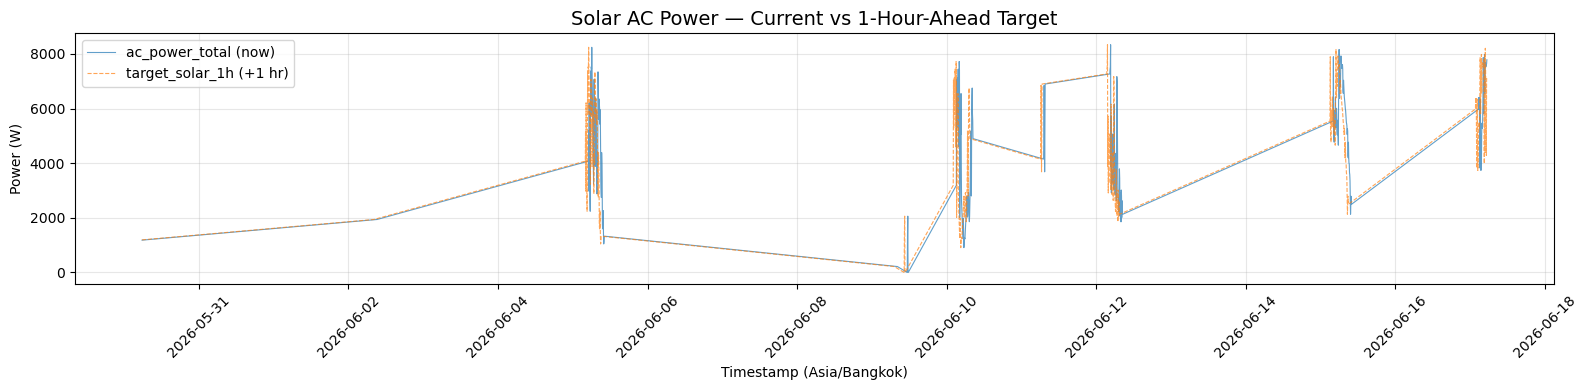

In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 13 — Exploratory Validation
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print(f"df.shape   : {df.shape}")
print("=" * 60)

print("\n── dtypes ──────────────────────────────────")
print(df.dtypes)

print("\n── describe ────────────────────────────────")
display(df.describe())

print("\n── null counts ─────────────────────────────")
print(df.isnull().sum())

# ── Plot ac_power_total vs target_solar_1h ────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

# Convert to Bangkok time for the plot axis
local_ts = df.index.tz_convert("Asia/Bangkok")

ax.plot(local_ts, df["ac_power_total"],   label="ac_power_total (now)",    alpha=0.7, linewidth=0.8)
ax.plot(local_ts, df["target_solar_1h"],  label="target_solar_1h (+1 hr)", alpha=0.7, linewidth=0.8, linestyle="--")

ax.set_title("Solar AC Power — Current vs 1-Hour-Ahead Target", fontsize=14)
ax.set_xlabel("Timestamp (Asia/Bangkok)")
ax.set_ylabel("Power (W)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# ─────────────────────────────────────────────────────────────
# CELL 14 — Feature Selection & Scaling (Dropping day_of_week)
# ─────────────────────────────────────────────────────────────

FEATURES = [
    "ac_power_total",
    "lag_1", "lag_2", "lag_3", "lag_4", "lag_6", "lag_7", "lag_8", "lag_9", "lag_10", "lag_11", "lag_12", "lag_288",
    "rolling_mean_6", "rolling_std_6", "rolling_mean_12", "rolling_mean_24",
    "solar_irradiance", "cloud_cover",
    "solar_irradiance_forecast_1h", "cloud_cover_forecast_1h",
    "hour_sin", "hour_cos"
]
TARGET = "target_solar_1h"

# Chronological 80/20 split
split_idx = int(len(df) * 0.8)
df_train = df.iloc[:split_idx]
df_val = df.iloc[split_idx:]

# Extract raw arrays
X_train_raw = df_train[FEATURES].values.astype(np.float32)
y_train_raw = df_train[TARGET].values.reshape(-1, 1).astype(np.float32)
X_val_raw = df_val[FEATURES].values.astype(np.float32)
y_val_raw = df_val[TARGET].values.reshape(-1, 1).astype(np.float32)

# Fit and scale features/targets
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_raw)
y_train_scaled = scaler_y.fit_transform(y_train_raw)

X_val_scaled = scaler_X.transform(X_val_raw)
y_val_scaled = scaler_y.transform(y_val_raw)

# Convert straight to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)

# Package into DataLoader
BATCH_SIZE = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [17]:
df_val

,ac_power_total,solar_irradiance,cloud_cover,cloud_cover_forecast_1h,solar_irradiance_forecast_1h,lag_1,lag_2,lag_3,lag_4,lag_6,...,lag_12,lag_288,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_mean_24,hour_sin,hour_cos,day_of_week,target_solar_1h
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-06-13 15:05:00+00:00,3674.407695,312.461823,93.453202,95.250000,0.0,3670.196335,3665.984975,3661.773616,3657.562256,3649.139537,...,3623.871379,2461.536128,3663.879296,7.878732,3651.245217,3625.977059,-4.809888e-01,0.876727,5,3724.944010
2026-06-13 15:10:00+00:00,3678.619054,312.381773,93.467980,95.500000,0.0,3674.407695,3670.196335,3665.984975,3661.773616,3653.350897,...,3628.082739,2465.747488,3668.090655,7.878732,3655.456576,3630.188419,-4.617486e-01,0.887011,5,3729.155369
2026-06-13 15:15:00+00:00,3682.830414,312.301724,93.482759,95.750000,0.0,3678.619054,3674.407695,3670.196335,3665.984975,3657.562256,...,3632.294099,2469.958847,3672.302015,7.878732,3659.667936,3634.399778,-4.422887e-01,0.896873,5,3733.366729
2026-06-13 15:20:00+00:00,3687.041773,312.221675,93.497537,96.000000,0.0,3682.830414,3678.619054,3674.407695,3670.196335,3661.773616,...,3636.505458,2474.170207,3676.513374,7.878732,3663.879296,3638.611138,-4.226183e-01,0.906308,5,3737.578089
2026-06-13 15:25:00+00:00,3691.253133,312.141626,93.512315,96.250000,0.0,3687.041773,3682.830414,3678.619054,3674.407695,3665.984975,...,3640.716818,2478.381567,3680.724734,7.878732,3668.090655,3642.822498,-4.027467e-01,0.915311,5,3741.789448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-17 05:00:00+00:00,7528.762500,515.000000,100.000000,69.000000,803.0,7579.192000,7677.488000,7684.522000,6551.416000,7255.182000,...,5638.826000,4127.647812,7498.904083,488.933318,7261.866875,6032.929521,1.224647e-16,-1.000000,2,6804.736667
2026-06-17 05:05:00+00:00,7541.302000,515.000000,100.000000,69.416667,805.5,7528.762500,7579.192000,7677.488000,7684.522000,7972.044000,...,6478.396000,4134.779243,7427.113750,434.117966,7350.442375,6187.874854,-2.181489e-02,-0.999762,2,6104.810000
2026-06-17 05:10:00+00:00,7586.932000,515.000000,100.000000,69.833333,808.0,7541.302000,7528.762500,7579.192000,7677.488000,6551.416000,...,7862.328000,4141.910675,7599.699750,66.740992,7327.492708,6321.624521,-4.361939e-02,-0.999048,2,4280.596000


In [18]:
# ─────────────────────────────────────────────────────────────
# CELL 15 — Define & Train the Multi-Layer Perceptron (MLP)
# ─────────────────────────────────────────────────────────────

class SolarForecastingMLP(nn.Module):
    def __init__(self, input_dim):
        super(SolarForecastingMLP, self).__init__()
        self.network = nn.Sequential(
            # Start much smaller (32 hidden units instead of 128)
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.4),  # Drop 40% of activations to prevent memorization
            
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(16, 1)  # Output
        )
        
    def forward(self, x):
        return self.network(x)

# Setup device execution structure (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SolarForecastingMLP(input_dim=len(FEATURES)).to(device)
criterion = nn.MSELoss()

# Lower learning rate (0.0005) and stronger weight decay (1e-3)
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-3)

# Standard training execution sequence with early stopping metrics tracking
EPOCHS = 150
best_val_loss = float('inf')
patience, patience_counter = 15, 0
best_model_state = None

print("🚀 Starting MLP Training loop...")
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * batch_X.size(0)
    
    train_loss /= len(train_loader.dataset)
    
    # Validation step
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_tensor.to(device))
        val_loss = criterion(val_preds, y_val_tensor.to(device)).item()
        
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        
    # Track performance for early stopping criteria
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"🛑 Early stopping triggered at Epoch {epoch+1}")
            break

# Restore optimized model weights
model.load_state_dict(best_model_state)
print("✅ Training complete.")

🚀 Starting MLP Training loop...
Epoch [1/150] | Train Loss: 0.8901 | Val Loss: 1.6646
Epoch [10/150] | Train Loss: 0.1675 | Val Loss: 0.1607
🛑 Early stopping triggered at Epoch 19
✅ Training complete.


In [19]:
# # ─────────────────────────────────────────────────────────────
# # CELL 15 — Define & Train the Multi-Layer Perceptron (MLP)
# # ─────────────────────────────────────────────────────────────

# class SolarForecastingMLP(nn.Module):
#     def __init__(self, input_dim):
#         super(SolarForecastingMLP, self).__init__()
#         self.network = nn.Sequential(
#             # Start much smaller (32 hidden units instead of 128)
#             nn.Linear(input_dim, 64),
#             nn.ReLU(),
#             nn.Dropout(0.4),  # Drop 40% of activations to prevent memorization
            
#             nn.Linear(64, 32),
#             nn.ReLU(),
#             nn.Dropout(0.3),
            
#             nn.Linear(32, 1)  # Output
#         )
        
#     def forward(self, x):
#         return self.network(x)

# # Setup device execution structure (GPU if available, else CPU)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = SolarForecastingMLP(input_dim=len(FEATURES)).to(device)
# criterion = nn.MSELoss()

# # Lower learning rate (0.0005) and stronger weight decay (1e-3)
# optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-3)

# # Standard training execution sequence with early stopping metrics tracking
# EPOCHS = 150
# best_val_loss = float('inf')
# patience, patience_counter = 15, 0
# best_model_state = None

# print("🚀 Starting MLP Training loop...")
# for epoch in range(EPOCHS):
#     model.train()
#     train_loss = 0.0
#     for batch_X, batch_y in train_loader:
#         batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
#         optimizer.zero_grad()
#         predictions = model(batch_X)
#         loss = criterion(predictions, batch_y)
#         loss.backward()
#         optimizer.step()
        
#         train_loss += loss.item() * batch_X.size(0)
    
#     train_loss /= len(train_loader.dataset)
    
#     # Validation step
#     model.eval()
#     with torch.no_grad():
#         val_preds = model(X_val_tensor.to(device))
#         val_loss = criterion(val_preds, y_val_tensor.to(device)).item()
        
#     if (epoch + 1) % 10 == 0 or epoch == 0:
#         print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        
#     # Track performance for early stopping criteria
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         best_model_state = model.state_dict().copy()
#         patience_counter = 0
#     else:
#         patience_counter += 1
#         if patience_counter >= patience:
#             print(f"🛑 Early stopping triggered at Epoch {epoch+1}")
#             break

# # Restore optimized model weights
# model.load_state_dict(best_model_state)
# print("✅ Training complete.")

In [20]:
# ─────────────────────────────────────────────────────────────
# CELL 16 — Evaluate Metrics (Inverting Normalization Transformations)
# ─────────────────────────────────────────────────────────────

model.eval()
with torch.no_grad():
    scaled_predictions = model(X_val_tensor.to(device)).cpu().numpy()

# REVERSE TRANSFORMATION: Scale arrays back to true-scale values (Watts)
y_pred_watts = scaler_y.inverse_transform(scaled_predictions)
y_val_watts = y_val_raw  # Keep unscaled baseline matrices

rmse_score = root_mean_squared_error(y_val_watts, y_pred_watts)
mae_score = mean_absolute_error(y_val_watts, y_pred_watts)

print("\n========================================")
print("     Validation Metrics (MLP Model)")
print("========================================")
print(f"  RMSE : {rmse_score:,.2f} W")
print(f"  MAE  : {mae_score:,.2f} W")
print("========================================")


     Validation Metrics (MLP Model)
  RMSE : 773.30 W
  MAE  : 581.07 W


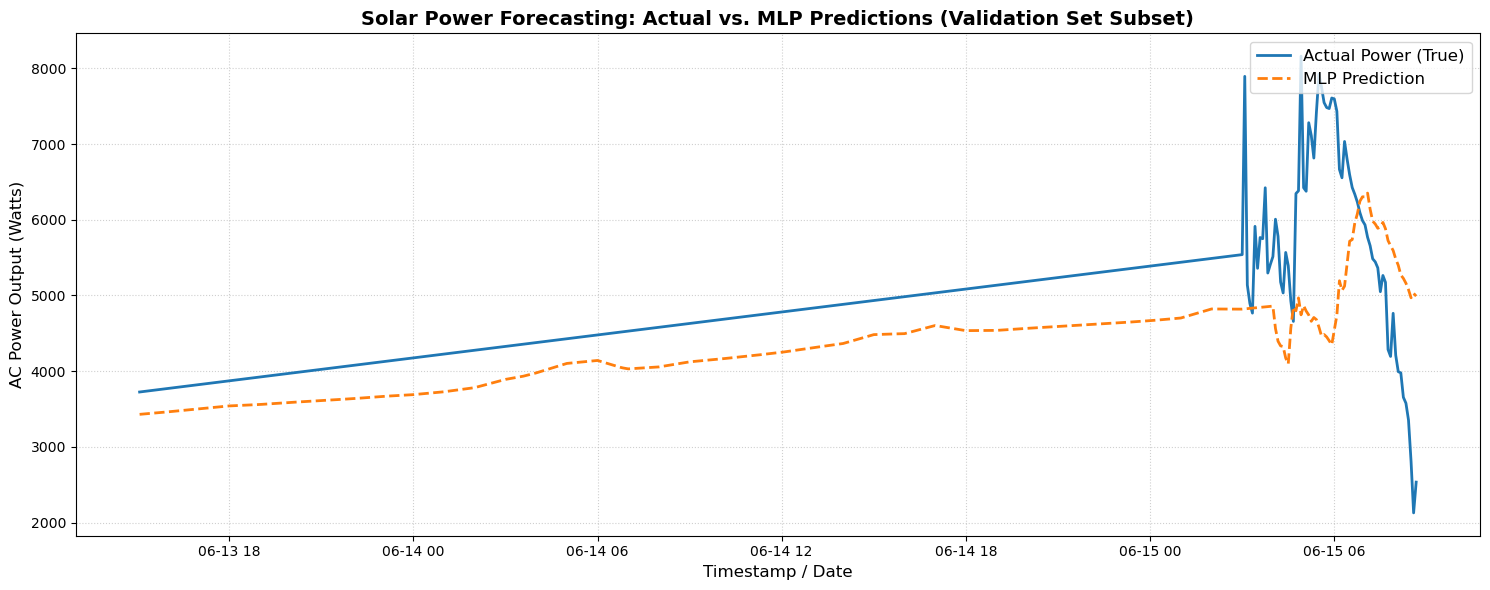

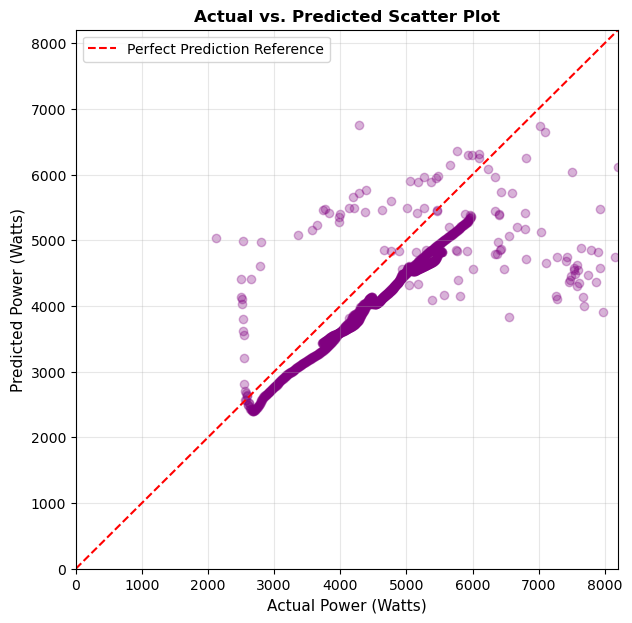

In [21]:
# ─────────────────────────────────────────────────────────────
# CELL 18 — Visualizing Actual vs. Predicted Solar Power
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

# 1. Reset index or extract timestamps for the validation partition
# This ensures your x-axis correctly displays real date/time tracking values
val_timestamps = df_val.index 

# 2. Create a structured DataFrame for clean plotting and slicing
plot_df = pd.DataFrame({
    'Actual Power': y_val_watts.flatten(),
    'MLP Prediction': y_pred_watts.flatten()
}, index=val_timestamps)

# 3. Plot the results
plt.figure(figsize=(15, 6))

# Let's plot a subset (e.g., the first 3 to 5 days of the validation set) 
# so the lines don't look like a solid block of color.
# You can change [:500] to a larger number or remove it completely to see the entire validation block.
plt.plot(plot_df['Actual Power'][:500], label='Actual Power (True)', color='#1f77b4', linewidth=2)
plt.plot(plot_df['MLP Prediction'][:500], label='MLP Prediction', color='#ff7f0e', linestyle='--', linewidth=2)

plt.title('Solar Power Forecasting: Actual vs. MLP Predictions (Validation Set Subset)', fontsize=14, fontweight='bold')
plt.xlabel('Timestamp / Date', fontsize=12)
plt.ylabel('AC Power Output (Watts)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()

# 4. Optional: Quick Scatter Plot to check for linear correlation
plt.figure(figsize=(7, 7))
plt.scatter(plot_df['Actual Power'], plot_df['MLP Prediction'], alpha=0.3, color='purple')
# Draw a perfect 1:1 baseline reference line
max_val = max(plot_df['Actual Power'].max(), plot_df['MLP Prediction'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Prediction Reference')

plt.title('Actual vs. Predicted Scatter Plot', fontsize=12, fontweight='bold')
plt.xlabel('Actual Power (Watts)', fontsize=11)
plt.ylabel('Predicted Power (Watts)', fontsize=11)
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

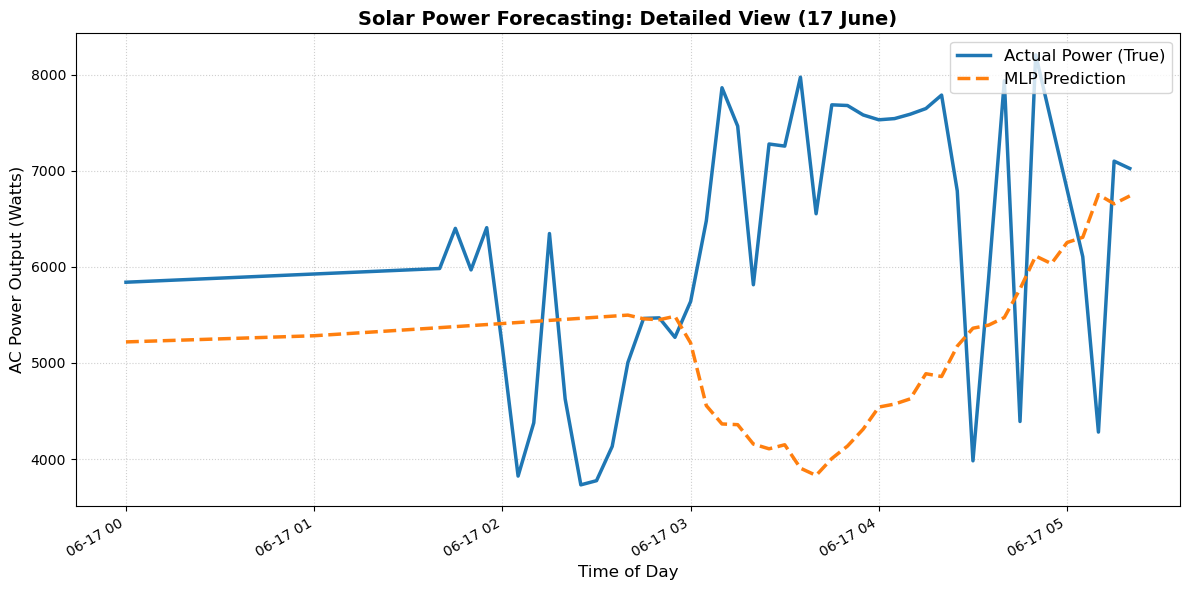

In [22]:
# ─────────────────────────────────────────────────────────────
# CELL 18 — Visualizing Actual vs. Predicted for 17 June
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

# 1. Rebuild the clean plotting DataFrame with the original index
plot_df = pd.DataFrame({
    'Actual Power': y_val_watts.flatten(),
    'MLP Prediction': y_pred_watts.flatten()
}, index=df_val.index)

# 2. Filter specifically for June 17, 2026
# (Note: If your dataset spans a different year, adjust '2026-06-17' accordingly)
single_day_df = plot_df.loc['2026-06-17']

# 3. Plot the narrow interval
plt.figure(figsize=(12, 6))

plt.plot(single_day_df['Actual Power'], label='Actual Power (True)', color='#1f77b4', linewidth=2.5)
plt.plot(single_day_df['MLP Prediction'], label='MLP Prediction', color='#ff7f0e', linestyle='--', linewidth=2.5)

plt.title('Solar Power Forecasting: Detailed View (17 June)', fontsize=14, fontweight='bold')
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('AC Power Output (Watts)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12, loc='upper right')

# Clean up x-axis formatting to show clean time intervals
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

In [23]:
# # Sanity check — confirm split is still roughly 80/20 on final df
# print(f"Train: {len(df_train)/len(df)*100:.1f}%  Val: {len(df_val)/len(df)*100:.1f}%")
# assert len(df_val) > 0, "Validation set is empty — check CUTOFF_TIME"

In [24]:
# # ─────────────────────────────────────────────────────────────
# # CELL 17 — Feature Importance
# # ─────────────────────────────────────────────────────────────

# importance_df = pd.DataFrame({
#     "feature": FEATURES,
#     "importance": model.get_feature_importance()
# })

# importance_df = importance_df.sort_values(
#     "importance",
#     ascending=False
# ).reset_index(drop=True)

# display(importance_df)

# plt.figure(figsize=(10, 7))
# plt.barh(
#     importance_df["feature"][:18][::-1],
#     importance_df["importance"][:18][::-1]
# )
# plt.title("CatBoost Feature Importance")
# plt.xlabel("Importance")
# plt.tight_layout()
# plt.show()